# SVD Analysis on Neural Networks with Configurable Dataset Size

This notebook performs SVD analysis on ResNet18 trained on CIFAR-10 with configurable training and test set sizes for faster experimentation.

In [11]:
# Configuration parameters
# Adjust these parameters to control dataset sizes for faster experimentation
TRAIN_SAMPLES = 2000  # Number of training samples to use (max: 50000)
TEST_SAMPLES = 500    # Number of test samples to use (max: 10000)
BATCH_SIZE = 128      # Batch size for training and testing

# Validate parameters
MAX_TRAIN_SAMPLES = 50000
MAX_TEST_SAMPLES = 10000

assert 1 <= TRAIN_SAMPLES <= MAX_TRAIN_SAMPLES, f"TRAIN_SAMPLES must be between 1 and {MAX_TRAIN_SAMPLES}"
assert 1 <= TEST_SAMPLES <= MAX_TEST_SAMPLES, f"TEST_SAMPLES must be between 1 and {MAX_TEST_SAMPLES}"
assert BATCH_SIZE > 0, "BATCH_SIZE must be positive"

print(f"Configuration:")
print(f"  Training samples: {TRAIN_SAMPLES:,} / {MAX_TRAIN_SAMPLES:,} ({TRAIN_SAMPLES/MAX_TRAIN_SAMPLES*100:.1f}%)")
print(f"  Test samples: {TEST_SAMPLES:,} / {MAX_TEST_SAMPLES:,} ({TEST_SAMPLES/MAX_TEST_SAMPLES*100:.1f}%)")
print(f"  Batch size: {BATCH_SIZE}")
print(f"\nTo change dataset size, modify TRAIN_SAMPLES and TEST_SAMPLES above and re-run this cell.")
print(f"Will train 5 models with different initializations for SVD analysis.")

Configuration:
  Training samples: 2,000 / 50,000 (4.0%)
  Test samples: 500 / 10,000 (5.0%)
  Batch size: 128

To change dataset size, modify TRAIN_SAMPLES and TEST_SAMPLES above and re-run this cell.
Will train 5 models with different initializations for SVD analysis.


## Configuration Instructions

This notebook trains **5 different models** with different initialization seeds and analyzes how initialization impacts SVD reconstruction quality.

To modify the experiment:

1. **Change `TRAIN_SAMPLES`**: Set to desired number of training samples (1 to 50,000)
2. **Change `TEST_SAMPLES`**: Set to desired number of test samples (1 to 10,000)  
3. **Change `BATCH_SIZE`**: Adjust batch size as needed
4. **Re-run the configuration cell** above to apply changes

**Recommended configurations for initialization study:**
- **Quick test**: `TRAIN_SAMPLES = 1000`, `TEST_SAMPLES = 200` (very fast)
- **Balanced**: `TRAIN_SAMPLES = 2000`, `TEST_SAMPLES = 500` (good balance)
- **Thorough**: `TRAIN_SAMPLES = 5000`, `TEST_SAMPLES = 1000` (more reliable results)

The notebook will train 5 models with seeds [42, 123, 456, 789, 999] and save each one individually.

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple
import copy
from tqdm import tqdm
import random

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Using device: mps


In [13]:
# Define transforms for CIFAR-10
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")
trainset_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset_full = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Create subsets based on configuration parameters
print(f"Creating subsets...")

# Create training subset
train_indices = list(range(len(trainset_full)))
random.shuffle(train_indices)
train_subset_indices = train_indices[:TRAIN_SAMPLES]
trainset = Subset(trainset_full, train_subset_indices)

# Create test subset
test_indices = list(range(len(testset_full)))
random.shuffle(test_indices)
test_subset_indices = test_indices[:TEST_SAMPLES]
testset = Subset(testset_full, test_subset_indices)

# Create data loaders
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# CIFAR-10 class names
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"Dataset loaded:")
print(f"  Full training set: {len(trainset_full)} samples")
print(f"  Using training subset: {len(trainset)} samples ({len(trainset)/len(trainset_full)*100:.1f}%)")
print(f"  Full test set: {len(testset_full)} samples")
print(f"  Using test subset: {len(testset)} samples ({len(testset)/len(testset_full)*100:.1f}%)")
print(f"Number of classes: {len(classes)}")

Loading CIFAR-10 dataset...
Creating subsets...
Dataset loaded:
  Full training set: 50000 samples
  Using training subset: 2000 samples (4.0%)
  Full test set: 10000 samples
  Using test subset: 500 samples (5.0%)
Number of classes: 10
Creating subsets...
Dataset loaded:
  Full training set: 50000 samples
  Using training subset: 2000 samples (4.0%)
  Full test set: 10000 samples
  Using test subset: 500 samples (5.0%)
Number of classes: 10


In [14]:
# Function to create a ResNet18 model for CIFAR-10 with specific initialization seed
def create_resnet18_cifar10(init_seed=42):
    """Create and initialize a ResNet18 model adapted for CIFAR-10."""
    # Set seed for this specific model initialization
    torch.manual_seed(init_seed)
    np.random.seed(init_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(init_seed)
    
    # Create standard ResNet18 and adapt it for CIFAR-10
    model = torchvision.models.resnet18(pretrained=False)  # No ImageNet pretraining
    
    # Modify the first conv layer for CIFAR-10's smaller image size (32x32)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()  # Remove maxpooling to preserve spatial dimensions
    
    # Modify the final layer for CIFAR-10 (10 classes)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 10)
    
    # Move model to device
    model = model.to(device)
    
    # Initialize weights with the specific seed
    def init_weights(m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
    
    model.apply(init_weights)
    return model

# Configuration for multiple models
NUM_MODELS = 5
INIT_SEEDS = [42, 123, 456, 789, 999]  # Different seeds for different initializations

print(f"Will create and train {NUM_MODELS} models with different initializations...")
print(f"Initialization seeds: {INIT_SEEDS}")

# Create the first model to check architecture
model = create_resnet18_cifar10(init_seed=INIT_SEEDS[0])
print(f"Model created with {sum(p.numel() for p in model.parameters())} total parameters")
print(f"Note: Each model will use random initialization with different seeds")
print(f"\nModel architecture:")
print(model)

Will create and train 5 models with different initializations...
Initialization seeds: [42, 123, 456, 789, 999]


/Users/christoffer/Documents/Thesis/repo/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model created with 11173962 total parameters
Note: Each model will use random initialization with different seeds

Model architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, aff

In [15]:
# Training function for CIFAR-10 with configurable parameters
def train_model_on_cifar10(model, trainloader, epochs=5, model_id=1):
    """Train a single model and return the trained model."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
    
    # Calculate reporting frequency based on dataset size
    num_batches = len(trainloader)
    report_freq = max(1, num_batches // 5)  # Report 5 times per epoch for faster training
    
    print(f"Training model {model_id} on {len(trainloader.dataset)} samples for {epochs} epochs...")
    
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (inputs, targets) in enumerate(trainloader):
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            if batch_idx % report_freq == 0:
                print(f'  Model {model_id}, Epoch: {epoch+1}/{epochs}, Batch: {batch_idx+1}/{num_batches}, '
                      f'Loss: {running_loss/(batch_idx+1):.3f}, Acc: {100.*correct/total:.2f}%')
        
        scheduler.step()
        print(f'  Model {model_id}, Epoch {epoch+1}/{epochs} completed. Train Acc: {100.*correct/total:.2f}%')
    
    return model

# Train multiple models with different initializations
print("="*60)
print("TRAINING MULTIPLE MODELS WITH DIFFERENT INITIALIZATIONS")
print("="*60)

trained_models = {}
model_performances = {}

# Adjust epochs based on dataset size - smaller datasets need more epochs for meaningful training
epochs = 15 if TRAIN_SAMPLES <= 1000 else 10 if TRAIN_SAMPLES <= 5000 else 5
print(f"Training each model for {epochs} epochs (adjusted for dataset size of {TRAIN_SAMPLES} samples)")

for i, seed in enumerate(INIT_SEEDS, 1):
    print(f"\n{'='*40}")
    print(f"Training Model {i}/5 (seed: {seed})")
    print(f"{'='*40}")
    
    # Create model with specific initialization
    model = create_resnet18_cifar10(init_seed=seed)
    
    # Train the model
    trained_model = train_model_on_cifar10(model, trainloader, epochs=epochs, model_id=i)
    
    # Save the model
    model_filename = f'resnet18_cifar10_model_{i}_seed_{seed}.pth'
    torch.save(trained_model.state_dict(), model_filename)
    print(f"  Model {i} saved as: {model_filename}")
    
    # Store the trained model
    trained_models[i] = trained_model
    
    # Quick evaluation
    trained_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in testloader:
            data, target = data.to(device), target.to(device)
            outputs = trained_model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    test_accuracy = 100 * correct / total
    model_performances[i] = test_accuracy
    print(f"  Model {i} Test Accuracy: {test_accuracy:.2f}%")

print(f"\n{'='*60}")
print("ALL MODELS TRAINED SUCCESSFULLY!")
print(f"{'='*60}")
print("Model Performance Summary:")
for i, acc in model_performances.items():
    print(f"  Model {i}: {acc:.2f}% test accuracy")

print(f"\nReady for SVD analysis on all {NUM_MODELS} models.")

TRAINING MULTIPLE MODELS WITH DIFFERENT INITIALIZATIONS
Training each model for 10 epochs (adjusted for dataset size of 2000 samples)

Training Model 1/5 (seed: 42)
Training model 1 on 2000 samples for 10 epochs...
Training model 1 on 2000 samples for 10 epochs...
  Model 1, Epoch: 1/10, Batch: 1/16, Loss: 17.921, Acc: 9.38%
  Model 1, Epoch: 1/10, Batch: 1/16, Loss: 17.921, Acc: 9.38%
  Model 1, Epoch: 1/10, Batch: 4/16, Loss: 13.669, Acc: 12.11%
  Model 1, Epoch: 1/10, Batch: 4/16, Loss: 13.669, Acc: 12.11%
  Model 1, Epoch: 1/10, Batch: 7/16, Loss: 11.077, Acc: 15.40%
  Model 1, Epoch: 1/10, Batch: 7/16, Loss: 11.077, Acc: 15.40%
  Model 1, Epoch: 1/10, Batch: 10/16, Loss: 10.508, Acc: 15.23%
  Model 1, Epoch: 1/10, Batch: 10/16, Loss: 10.508, Acc: 15.23%
  Model 1, Epoch: 1/10, Batch: 13/16, Loss: 10.036, Acc: 16.23%
  Model 1, Epoch: 1/10, Batch: 13/16, Loss: 10.036, Acc: 16.23%
  Model 1, Epoch: 1/10, Batch: 16/16, Loss: 9.633, Acc: 17.65%
  Model 1, Epoch: 1/10, Batch: 16/16, Lo

In [16]:
# save the model state dict for future use
#torch.save(model.state_dict(), 'resnet18_cifar10.pth')

# load the model state dict
#model.load_state_dict(torch.load('resnet18_cifar10.pth'))


## 4. Extract Weight Matrices from All Models

In [17]:
def extract_linear_layers(model):
    """Extract all linear layers from the model."""
    linear_layers = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            linear_layers[name] = module
    return linear_layers

def extract_conv_layers(model):
    """Extract all convolutional layers from the model."""
    conv_layers = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            conv_layers[name] = module
    return conv_layers

# Extract layers for SVD analysis from all models
all_models_layers = {}

print("Extracting layers from all trained models...")
for model_id, model in trained_models.items():
    linear_layers = extract_linear_layers(model)
    conv_layers = extract_conv_layers(model)
    
    all_models_layers[model_id] = {
        'linear': linear_layers,
        'conv': conv_layers
    }
    
    print(f"\nModel {model_id}:")
    print(f"  Found {len(linear_layers)} linear layers:")
    for name, layer in linear_layers.items():
        print(f"    {name}: {layer.weight.shape}")
    
    print(f"  Found {len(conv_layers)} convolutional layers:")
    for name, layer in list(conv_layers.items())[:3]:  # Show first 3 only
        print(f"    {name}: {layer.weight.shape}")
    if len(conv_layers) > 3:
        print(f"    ... and {len(conv_layers) - 3} more conv layers")

print(f"\nLayer extraction completed for all {NUM_MODELS} models.")

Extracting layers from all trained models...

Model 1:
  Found 1 linear layers:
    fc: torch.Size([10, 512])
  Found 20 convolutional layers:
    conv1: torch.Size([64, 3, 3, 3])
    layer1.0.conv1: torch.Size([64, 64, 3, 3])
    layer1.0.conv2: torch.Size([64, 64, 3, 3])
    ... and 17 more conv layers

Model 2:
  Found 1 linear layers:
    fc: torch.Size([10, 512])
  Found 20 convolutional layers:
    conv1: torch.Size([64, 3, 3, 3])
    layer1.0.conv1: torch.Size([64, 64, 3, 3])
    layer1.0.conv2: torch.Size([64, 64, 3, 3])
    ... and 17 more conv layers

Model 3:
  Found 1 linear layers:
    fc: torch.Size([10, 512])
  Found 20 convolutional layers:
    conv1: torch.Size([64, 3, 3, 3])
    layer1.0.conv1: torch.Size([64, 64, 3, 3])
    layer1.0.conv2: torch.Size([64, 64, 3, 3])
    ... and 17 more conv layers

Model 4:
  Found 1 linear layers:
    fc: torch.Size([10, 512])
  Found 20 convolutional layers:
    conv1: torch.Size([64, 3, 3, 3])
    layer1.0.conv1: torch.Size([64, 6

## 5. Apply SVD to Weight Matrices from All Models

Analyzing SVD for final linear layer (fc) from all models...

Model 1 SVD analysis for final linear layer (fc):
  Original weight shape: torch.Size([10, 512])
  Number of singular values: 10
  Largest singular values: [11.058692 10.863727 10.552513]
  Smallest singular values: [9.321756 8.664371 8.41499 ]

Model 2 SVD analysis for final linear layer (fc):
  Original weight shape: torch.Size([10, 512])
  Number of singular values: 10
  Largest singular values: [11.23345  10.73474  10.652792]
  Smallest singular values: [9.374653  9.0798855 8.957345 ]

Model 3 SVD analysis for final linear layer (fc):
  Original weight shape: torch.Size([10, 512])
  Number of singular values: 10
  Largest singular values: [11.1514   10.554626 10.275797]
  Smallest singular values: [9.245141 9.177399 8.563226]

Model 4 SVD analysis for final linear layer (fc):
  Original weight shape: torch.Size([10, 512])
  Number of singular values: 10
  Largest singular values: [11.145006 10.901158 10.535161]
  Smalles

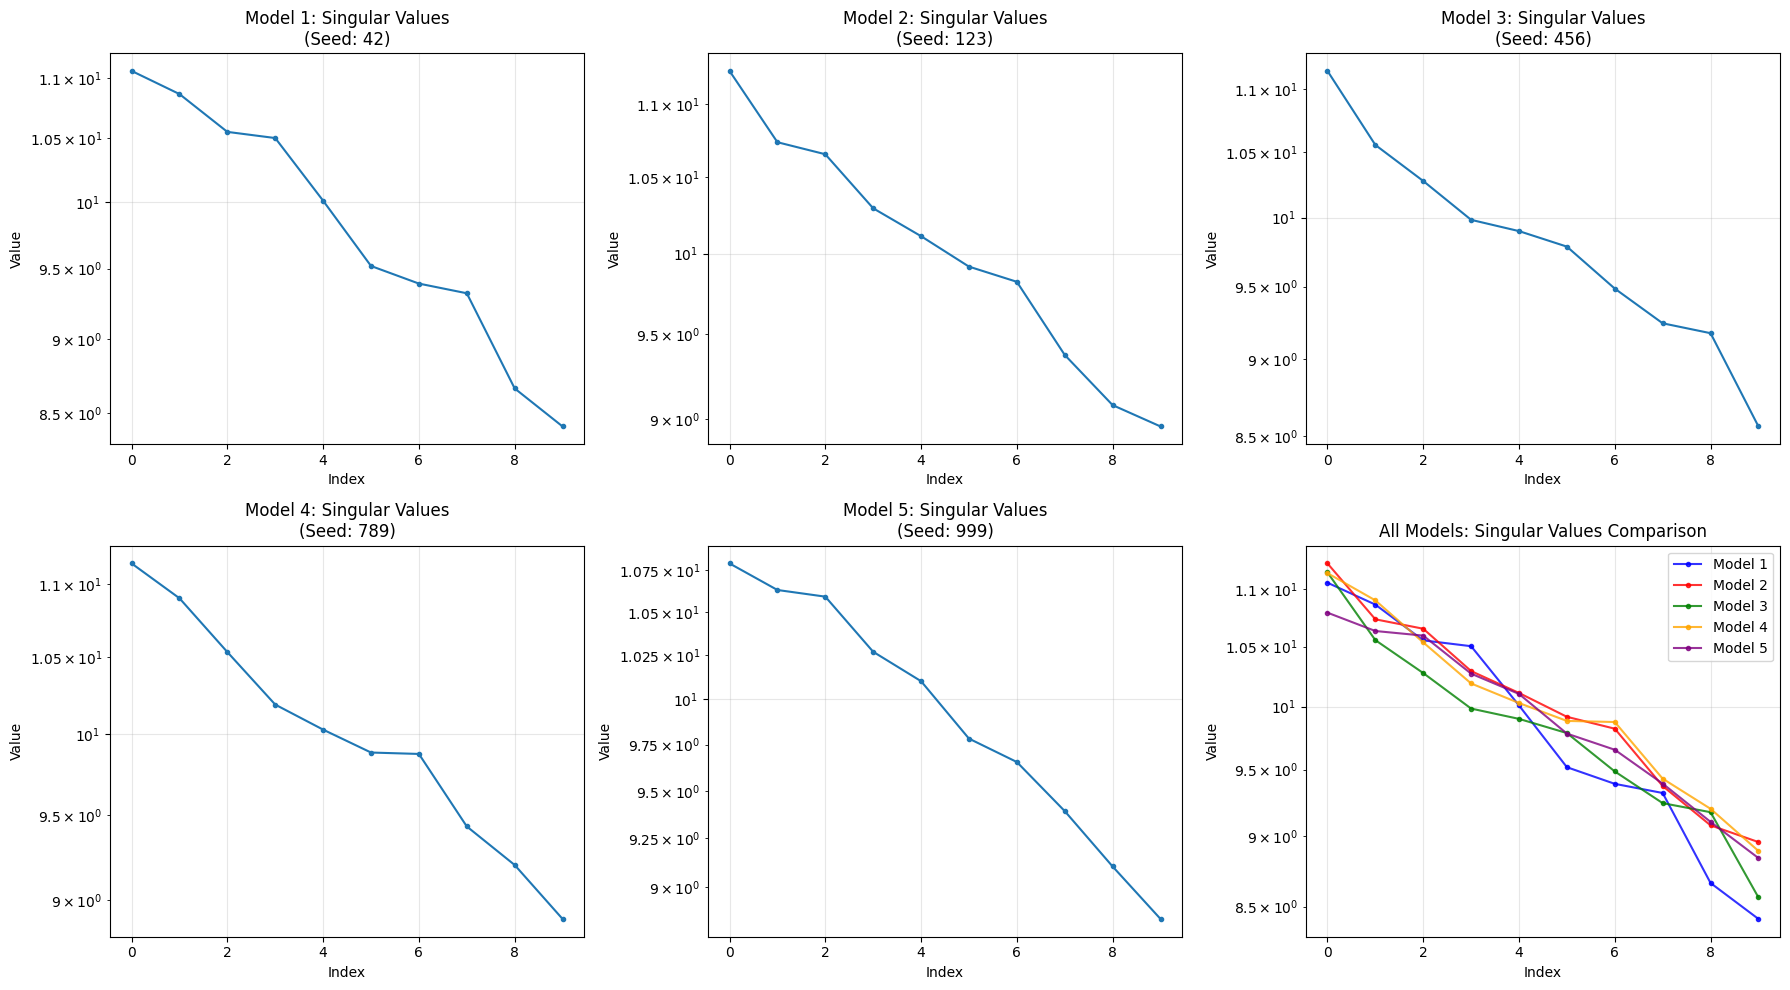


SVD analysis completed for all 5 models.


In [18]:
def apply_svd_to_weight(weight_matrix):
    """Apply SVD to a weight matrix and return U, S, V."""
    # Convert to numpy for SVD computation
    weight_np = weight_matrix.detach().cpu().numpy()
    
    # For conv layers, reshape to 2D matrix
    original_shape = weight_np.shape
    if len(original_shape) == 4:  # Conv2d weights: (out_channels, in_channels, H, W)
        weight_np = weight_np.reshape(original_shape[0], -1)
    
    # Apply SVD
    U, S, Vt = np.linalg.svd(weight_np, full_matrices=False)
    
    return U, S, Vt, original_shape

def reconstruct_weight_with_k_components(U, S, Vt, k, original_shape, device):
    """Reconstruct weight matrix using only k singular values."""
    # Truncate to k components
    U_k = U[:, :k]
    S_k = S[:k]
    Vt_k = Vt[:k, :]
    
    # Reconstruct
    reconstructed = U_k @ np.diag(S_k) @ Vt_k
    
    # Reshape back to original shape if needed
    if len(original_shape) == 4:
        reconstructed = reconstructed.reshape(original_shape)
    
    # Convert back to tensor
    return torch.tensor(reconstructed, dtype=torch.float32, device=device)

# Analyze SVD for the final linear layer (fc) from all models
print("Analyzing SVD for final linear layer (fc) from all models...")

all_models_svd_info = {}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for model_id, model in trained_models.items():
    fc_layer = all_models_layers[model_id]['linear']['fc']
    U, S, Vt, original_shape = apply_svd_to_weight(fc_layer.weight)
    
    all_models_svd_info[model_id] = {
        'fc': {
            'U': U, 'S': S, 'Vt': Vt, 'original_shape': original_shape,
            'total_components': len(S)
        }
    }
    
    print(f"\nModel {model_id} SVD analysis for final linear layer (fc):")
    print(f"  Original weight shape: {fc_layer.weight.shape}")
    print(f"  Number of singular values: {len(S)}")
    print(f"  Largest singular values: {S[:3]}")
    print(f"  Smallest singular values: {S[-3:]}")
    
    # Plot singular values for this model
    ax_idx = model_id - 1
    axes[ax_idx].plot(S, 'o-', markersize=3, linewidth=1.5)
    axes[ax_idx].set_title(f'Model {model_id}: Singular Values\n(Seed: {INIT_SEEDS[model_id-1]})')
    axes[ax_idx].set_xlabel('Index')
    axes[ax_idx].set_ylabel('Value')
    axes[ax_idx].set_yscale('log')
    axes[ax_idx].grid(True, alpha=0.3)

# Plot comparison of all models
axes[5].clear()
colors = ['blue', 'red', 'green', 'orange', 'purple']
for model_id in range(1, NUM_MODELS + 1):
    S = all_models_svd_info[model_id]['fc']['S']
    axes[5].plot(S, 'o-', color=colors[model_id-1], label=f'Model {model_id}', 
                markersize=3, linewidth=1.5, alpha=0.8)

axes[5].set_title('All Models: Singular Values Comparison')
axes[5].set_xlabel('Index')
axes[5].set_ylabel('Value')
axes[5].set_yscale('log')
axes[5].legend()
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSVD analysis completed for all {NUM_MODELS} models.")

## 6. Reconstruct All Models with Reduced Rank Weights

In [19]:
def create_svd_compressed_model(original_model, target_layers, k_values):
    """
    Create a compressed model using SVD with k singular values for specified layers.
    
    Args:
        original_model: The original model
        target_layers: Dict of layer names to compress
        k_values: Dict mapping layer names to number of singular values to keep
    """
    # Create a deep copy of the model
    compressed_model = copy.deepcopy(original_model)
    
    # Apply SVD compression to specified layers
    for layer_name, k in k_values.items():
        if layer_name in target_layers:
            layer = dict(compressed_model.named_modules())[layer_name]
            
            # Apply SVD to the weight
            U, S, Vt, original_shape = apply_svd_to_weight(layer.weight)
            
            # Reconstruct with k components
            reconstructed_weight = reconstruct_weight_with_k_components(
                U, S, Vt, k, original_shape, device
            )
            
            # Update the layer weight
            layer.weight.data = reconstructed_weight
    
    return compressed_model

# Create compressed models for all trained models
print("Creating SVD compressed models for all trained models...")

# Determine k values to test (use same range for all models for comparison)
max_components = min([all_models_svd_info[i]['fc']['total_components'] for i in range(1, NUM_MODELS + 1)])
k_values_list = list(range(1, max_components + 1, max(1, max_components // 10)))  # Sample ~10 points
if max_components not in k_values_list:
    k_values_list.append(max_components)  # Always include full rank

print(f"Testing k values: {k_values_list}")
print(f"Maximum components across all models: {max_components}")

all_compressed_models = {}

for model_id in range(1, NUM_MODELS + 1):
    print(f"\nCreating compressed versions of Model {model_id}...")
    
    original_model = trained_models[model_id]
    linear_layers = all_models_layers[model_id]['linear']
    
    compressed_models = {}
    
    for k in k_values_list:
        if k <= all_models_svd_info[model_id]['fc']['total_components']:
            k_dict = {'fc': k}
            compressed_models[k] = create_svd_compressed_model(original_model, linear_layers, k_dict)
    
    all_compressed_models[model_id] = compressed_models
    print(f"  Created {len(compressed_models)} compressed versions of Model {model_id}")

print(f"\nSVD compression completed for all {NUM_MODELS} models.")
print(f"Each model has {len(k_values_list)} compressed versions (including original).")

Creating SVD compressed models for all trained models...
Testing k values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Maximum components across all models: 10

Creating compressed versions of Model 1...
  Created 10 compressed versions of Model 1

Creating compressed versions of Model 2...
  Created 10 compressed versions of Model 2

Creating compressed versions of Model 3...
  Created 10 compressed versions of Model 3

Creating compressed versions of Model 4...
  Created 10 compressed versions of Model 4

Creating compressed versions of Model 5...
  Created 10 compressed versions of Model 5

SVD compression completed for all 5 models.
Each model has 10 compressed versions (including original).
  Created 10 compressed versions of Model 3

Creating compressed versions of Model 4...
  Created 10 compressed versions of Model 4

Creating compressed versions of Model 5...
  Created 10 compressed versions of Model 5

SVD compression completed for all 5 models.
Each model has 10 compressed versions (inc

## 7. Evaluate Performance Across All Models

In [20]:
def evaluate_model(model, dataloader, max_batches=None):
    """Evaluate model accuracy on a dataset."""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(dataloader):
            if max_batches and batch_idx >= max_batches:
                break
                
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

def evaluate_all_compressed_models(all_compressed_models, trainloader, testloader, max_batches=None):
    """Evaluate all compressed models and return results."""
    all_results = {}
    
    print("Evaluating all compressed models...")
    
    for model_id in tqdm(range(1, NUM_MODELS + 1), desc="Models"):
        print(f"\nEvaluating Model {model_id} compressed versions...")
        
        model_results = {}
        compressed_models = all_compressed_models[model_id]
        
        for k in tqdm(sorted(compressed_models.keys()), desc=f"Model {model_id} k-values", leave=False):
            model = compressed_models[k]
            
            # Evaluate on training set
            train_acc = evaluate_model(model, trainloader, max_batches=max_batches)
            
            # Evaluate on test set
            test_acc = evaluate_model(model, testloader, max_batches=max_batches)
            
            model_results[k] = {
                'train_accuracy': train_acc,
                'test_accuracy': test_acc
            }
            
            print(f"  Model {model_id}, k={k}: Train={train_acc:.2f}%, Test={test_acc:.2f}%")
        
        all_results[model_id] = model_results
    
    return all_results

# Calculate appropriate number of batches for evaluation based on dataset size
max_eval_batches = None if len(trainloader.dataset) <= 5000 else len(trainloader) // 2
print(f"Will evaluate on {'full dataset' if max_eval_batches is None else f'first {max_eval_batches} batches'}")

# Evaluate all compressed models
print("="*60)
print("EVALUATING ALL COMPRESSED MODELS")
print("="*60)

all_evaluation_results = evaluate_all_compressed_models(
    all_compressed_models, trainloader, testloader, max_batches=max_eval_batches
)

print(f"\n{'='*60}")
print("EVALUATION COMPLETED!")
print(f"{'='*60}")
print("Summary of results available for visualization.")

Will evaluate on full dataset
EVALUATING ALL COMPRESSED MODELS
Evaluating all compressed models...


Models:   0%|          | 0/5 [00:00<?, ?it/s]


Evaluating Model 1 compressed versions...


Model 1 k-values:   0%|          | 0/10 [00:00<?, ?it/s]

  Model 1, k=1: Train=11.30%, Test=11.00%


...

  Model 5, k=8: Train=26.20%, Test=23.00%


Model 5 k-values:  90%|█████████ | 9/10 [04:14<00:28, 28.30s/it]

  Model 5, k=9: Train=36.30%, Test=29.20%


Models: 100%|██████████| 5/5 [25:34<00:00, 306.99s/it] 28.29s/it]

  Model 5, k=10: Train=39.85%, Test=31.80%

EVALUATION COMPLETED!
Summary of results available for visualization.


## 8. Compare Results Across Multiple Initializations

In [21]:
# Analyze results and prepare data for visualization
print("Analyzing results across all models...")

# Extract k values that are common to all models
common_k_values = sorted(list(set.intersection(*[set(all_evaluation_results[i].keys()) 
                                                for i in range(1, NUM_MODELS + 1)])))

print(f"Common k values across all models: {common_k_values}")

# Prepare data for plotting
results_summary = {
    'k_values': common_k_values,
    'models': {}
}

for model_id in range(1, NUM_MODELS + 1):
    train_accs = [all_evaluation_results[model_id][k]['train_accuracy'] for k in common_k_values]
    test_accs = [all_evaluation_results[model_id][k]['test_accuracy'] for k in common_k_values]
    
    results_summary['models'][model_id] = {
        'train_accuracies': train_accs,
        'test_accuracies': test_accs,
        'seed': INIT_SEEDS[model_id - 1]
    }

# Calculate statistics across models
mean_train_accs = []
std_train_accs = []
mean_test_accs = []
std_test_accs = []

for i, k in enumerate(common_k_values):
    train_vals = [results_summary['models'][m]['train_accuracies'][i] for m in range(1, NUM_MODELS + 1)]
    test_vals = [results_summary['models'][m]['test_accuracies'][i] for m in range(1, NUM_MODELS + 1)]
    
    mean_train_accs.append(np.mean(train_vals))
    std_train_accs.append(np.std(train_vals))
    mean_test_accs.append(np.mean(test_vals))
    std_test_accs.append(np.std(test_vals))

results_summary['statistics'] = {
    'mean_train': mean_train_accs,
    'std_train': std_train_accs,
    'mean_test': mean_test_accs,
    'std_test': std_test_accs
}

print("\nResults Summary:")
print("k\tMean Train ± Std\tMean Test ± Std")
print("-" * 50)
for i, k in enumerate(common_k_values):
    print(f"{k}\t{mean_train_accs[i]:.2f} ± {std_train_accs[i]:.2f}\t\t{mean_test_accs[i]:.2f} ± {std_test_accs[i]:.2f}")

print(f"\nData prepared for visualization with {NUM_MODELS} models and {len(common_k_values)} k-values.")

Analyzing results across all models...
Common k values across all models: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Results Summary:
k	Mean Train ± Std	Mean Test ± Std
--------------------------------------------------
1	11.75 ± 1.74		11.44 ± 0.94
2	17.72 ± 4.53		16.08 ± 3.20
3	21.48 ± 6.38		16.48 ± 4.05
4	24.06 ± 6.61		17.00 ± 3.38
5	31.05 ± 6.80		20.40 ± 3.81
6	35.86 ± 8.66		21.48 ± 4.49
7	41.43 ± 11.42		24.04 ± 5.10
8	48.74 ± 12.76		27.44 ± 3.52
9	56.77 ± 11.09		31.24 ± 3.20
10	64.37 ± 13.16		35.36 ± 2.31

Data prepared for visualization with 5 models and 10 k-values.


## 9. Visualize Impact of Initialization on SVD Reconstruction

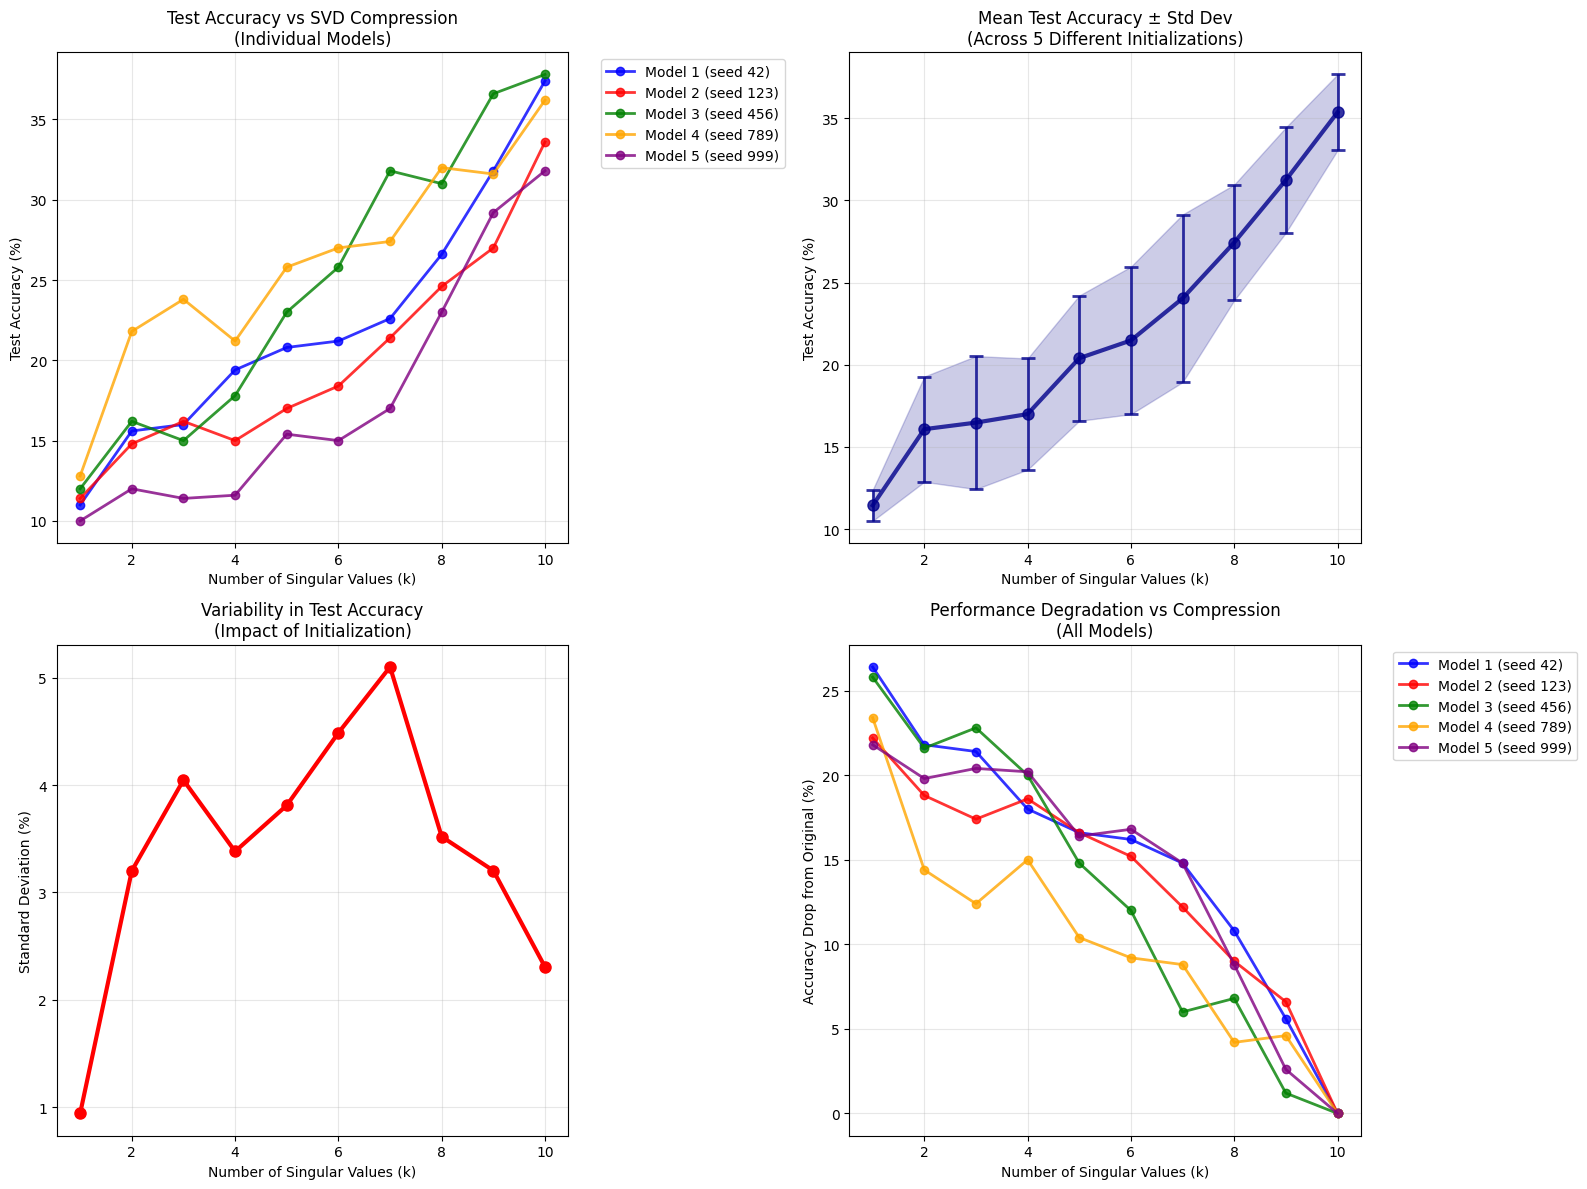


SUMMARY: IMPACT OF INITIALIZATION ON SVD RECONSTRUCTION

Dataset: 2000 train samples, 500 test samples
Models: 5 different initializations
Seeds used: [42, 123, 456, 789, 999]

Variability Analysis:
  Highest variability: k=7, std=5.10%
  Lowest variability:  k=1, std=0.94%
  Mean variability across all k: 3.40%

Performance at different compression levels:
  k=1 (10.0% of original): 11.44% ± 0.94%
  k=4 (40.0% of original): 17.00% ± 3.38%
  k=7 (70.0% of original): 24.04% ± 5.10%
  k=10 (100.0% of original): 35.36% ± 2.31%

Conclusion: High impact of initialization on SVD reconstruction (avg std: 3.40%)


In [22]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = ['blue', 'red', 'green', 'orange', 'purple']
k_values = results_summary['k_values']

# Plot 1: Individual model performance (Test Accuracy)
ax1 = axes[0, 0]
for model_id in range(1, NUM_MODELS + 1):
    test_accs = results_summary['models'][model_id]['test_accuracies']
    seed = results_summary['models'][model_id]['seed']
    ax1.plot(k_values, test_accs, 'o-', color=colors[model_id-1], 
             label=f'Model {model_id} (seed {seed})', linewidth=2, markersize=6, alpha=0.8)

ax1.set_xlabel('Number of Singular Values (k)')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Test Accuracy vs SVD Compression\n(Individual Models)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Mean performance with error bars
ax2 = axes[0, 1]
mean_test = results_summary['statistics']['mean_test']
std_test = results_summary['statistics']['std_test']

ax2.errorbar(k_values, mean_test, yerr=std_test, 
             fmt='o-', color='darkblue', linewidth=3, markersize=8, 
             capsize=5, capthick=2, elinewidth=2, alpha=0.8)
ax2.fill_between(k_values, 
                 np.array(mean_test) - np.array(std_test),
                 np.array(mean_test) + np.array(std_test),
                 alpha=0.2, color='darkblue')

ax2.set_xlabel('Number of Singular Values (k)')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title(f'Mean Test Accuracy ± Std Dev\n(Across {NUM_MODELS} Different Initializations)')
ax2.grid(True, alpha=0.3)

# Plot 3: Variability across initializations
ax3 = axes[1, 0]
ax3.plot(k_values, std_test, 'ro-', linewidth=3, markersize=8)
ax3.set_xlabel('Number of Singular Values (k)')
ax3.set_ylabel('Standard Deviation (%)')
ax3.set_title('Variability in Test Accuracy\n(Impact of Initialization)')
ax3.grid(True, alpha=0.3)

# Plot 4: Performance drop from original
ax4 = axes[1, 1]
original_k = max(k_values)
original_idx = k_values.index(original_k)

for model_id in range(1, NUM_MODELS + 1):
    test_accs = results_summary['models'][model_id]['test_accuracies']
    original_acc = test_accs[original_idx]
    drops = [original_acc - acc for acc in test_accs]
    seed = results_summary['models'][model_id]['seed']
    
    ax4.plot(k_values, drops, 'o-', color=colors[model_id-1], 
             label=f'Model {model_id} (seed {seed})', linewidth=2, markersize=6, alpha=0.8)

ax4.set_xlabel('Number of Singular Values (k)')
ax4.set_ylabel('Accuracy Drop from Original (%)')
ax4.set_title('Performance Degradation vs Compression\n(All Models)')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY: IMPACT OF INITIALIZATION ON SVD RECONSTRUCTION")
print("="*60)

print(f"\nDataset: {TRAIN_SAMPLES} train samples, {TEST_SAMPLES} test samples")
print(f"Models: {NUM_MODELS} different initializations")
print(f"Seeds used: {INIT_SEEDS}")

print(f"\nVariability Analysis:")
max_std_idx = np.argmax(std_test)
min_std_idx = np.argmin(std_test)
print(f"  Highest variability: k={k_values[max_std_idx]}, std={std_test[max_std_idx]:.2f}%")
print(f"  Lowest variability:  k={k_values[min_std_idx]}, std={std_test[min_std_idx]:.2f}%")
print(f"  Mean variability across all k: {np.mean(std_test):.2f}%")

print(f"\nPerformance at different compression levels:")
for i, k in enumerate(k_values[::max(1, len(k_values)//3)]):  # Show ~3 representative points
    idx = k_values.index(k)
    compression_ratio = k / max(k_values) * 100
    print(f"  k={k} ({compression_ratio:.1f}% of original): {mean_test[idx]:.2f}% ± {std_test[idx]:.2f}%")

print(f"\nConclusion: {'High' if np.mean(std_test) > 2 else 'Moderate' if np.mean(std_test) > 1 else 'Low'} "
      f"impact of initialization on SVD reconstruction (avg std: {np.mean(std_test):.2f}%)")